In [1]:
import pandas as pd
import ast
import io
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

import torch
import torch.nn as nn
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

import plotly.express as px

In [2]:
# Step 1: Manual File Selection
print("Please upload your 'trunc_mtg_final_classified_deck.csv' file:")
uploaded = files.upload()

# Step 2: Read the file
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Step 3: Handle the [] empty data as requested
def mark_empty_data(tag_str):
    """
    Converts stringified lists to actual lists.
    Replaces empty lists [] with a specific marker for the Self-Attention layer.
    """
    try:
        # Check if it's a string representation of a list
        if isinstance(tag_str, str):
            tags = ast.literal_eval(tag_str)
        else:
            tags = tag_str

        # If it's a list but empty, or if it's NaN
        if not tags or (isinstance(tags, list) and len(tags) == 0):
            return ["EMPTY_DATA"]
        return tags
    except (ValueError, SyntaxError):
        # Handle cases where data might be missing or malformed
        return ["EMPTY_DATA"]

# Apply the marker to your key columns
df['manual_tags'] = df['manual_tags'].apply(mark_empty_data)
df['generated_effect_tags'] = df['generated_effect_tags'].apply(mark_empty_data)

# Print a quick check for cards like Wound Reflection
print("\nSample Check (Empty Data Handling):")
print(df[['name', 'generated_effect_tags']].tail())

Please upload your 'trunc_mtg_final_classified_deck.csv' file:


Saving trunc_mtg_final_classified_deck.csv to trunc_mtg_final_classified_deck.csv

Sample Check (Empty Data Handling):
                     name                    generated_effect_tags
495  Tishana's Tidebinder    [Counter, Flash, Disruption, Control]
496     Vantress Gargoyle              [Graveyard Ramp, Mill Ramp]
497              War Room          [Color Fixer, Card Draw Engine]
498              Windfall  [Discard Mechanic, Resource Generation]
499       The Mindskinner               [Mind Control, Mindbender]


In [3]:
class MTGDiscoveryModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_heads=4, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)

        self.encoder = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 16)
        )
        self.decoder = nn.Sequential(nn.Linear(16, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, embed_dim))

    def forward(self, x, temperature=1.0):
        # x: [Batch, 100, Tokens]
        card_embeddings = self.embedding(x).mean(dim=2)

        # Scaling by temperature to tune "harshness"
        # Since MultiheadAttention is a wrapper, we scale the embeddings
        # as a proxy for scaling the dot product inside.
        scaled_embeddings = card_embeddings / temperature

        attn_output, attn_weights = self.attention(scaled_embeddings, scaled_embeddings, scaled_embeddings)

        latent = self.encoder(attn_output)
        reconstructed = self.decoder(latent)

        return attn_weights, latent, reconstructed

In [4]:
##### Function for preprocessing all tags to ensure no crash if met with discrepancy
def process_tags(x):
    try:
        tags = ast.literal_eval(x)
        return tags if (isinstance(tags, list) and len(tags) > 0) else ["EMPTY_DATA"]
    except:
        return ["EMPTY_DATA"]

def get_tokens(text, is_mana=False):
    if pd.isna(text) or text == "": return []
    text = str(text).lower()

    if is_mana:
        return re.findall(r'\{.*?\}', text)

    # Extract words
    words = re.findall(r'\b[a-z]{3,}\b', text)

    # THE FILTER: Only keep the word if it is NOT in our STOPWORDS list
    return [w for w in words if w not in STOPWORDS]

def clean_description(text):
    if pd.isna(text): return ""
    # Remove the noise words from the string
    words = text.lower().split()
    cleaned = [w for w in words if w not in STOPWORDS]
    return " ".join(cleaned)

def prepare_data(df):
    def parse_tags(x):
        try:
            tags = ast.literal_eval(x) if isinstance(x, str) else x
            return tags if (isinstance(tags, list) and len(tags) > 0) else ["EMPTY_DATA"]
        except: return ["EMPTY_DATA"]

    # 1. Clean the core tag columns
    df['gen_tags'] = df['generated_effect_tags'].apply(parse_tags)
    df['man_tags'] = df['manual_tags'].apply(parse_tags)

    # 2. Extract tokens for the vocabulary
    all_tags = [t for sub in df['gen_tags'].tolist() + df['man_tags'].tolist() for t in sub]

    # Text-based features
    all_words = []
    for txt in df['effects_line']: all_words.extend(get_tokens(txt))
    for txt in df['type_line']: all_words.extend(get_tokens(txt))

    # Mana-specific symbols
    all_mana = []
    for m in df['mana_cost']: all_mana.extend(get_tokens(m, is_mana=True))
    for m in df['mana_production']: all_mana.extend(get_tokens(m, is_mana=True))

    # Build the final Master Vocab
    common_words = [w for w, c in Counter(all_words).most_common(400)]
    unique_mana = list(set(all_mana))

    master_vocab = sorted(list(set(all_tags + common_words + unique_mana)))
    t2i = {tok: i + 1 for i, tok in enumerate(master_vocab)}
    t2i["PAD"] = 0
    t2i["EMPTY_DATA"] = t2i.get("EMPTY_DATA", len(t2i))

    return df, t2i

In [5]:
def run_deck_analysis(deck_id, deck_df, model, tag_to_idx, temp=1.0, max_tokens=30):
    deck_df = deck_df.sort_values(by='is_commander', ascending=False).reset_index(drop=True)
    labels = [f"⭐ {n}" if c else n for n, c in zip(deck_df['name'], deck_df['is_commander'])]

    indexed_deck = []
    for _, row in deck_df.iterrows():
        # Because get_tokens now ignores STOPWORDS, your heatmap
        # will only represent the relationship between MECHANICAL tokens.
        tokens = (
            row['gen_tags'] +
            row['man_tags'] +
            get_tokens(row['effects_line']) + # Now ignores 'you', 'the', etc.
            get_tokens(row['type_line']) +
            get_tokens(row['mana_cost'], is_mana=True) +
            get_tokens(row['mana_production'], is_mana=True)
        )

        indices = [tag_to_idx[t] for t in tokens if t in tag_to_idx]
        indices = indices[:max_tokens] + [0] * (max_tokens - len(indices))
        indexed_deck.append(indices)

    # Inference
    deck_tensor = torch.LongTensor([indexed_deck])
    model.eval()
    with torch.no_grad():
        weights, latent, _ = model(deck_tensor, temperature=temp)

    # Plot
    plt.figure(figsize=(18, 15))
    sns.heatmap(weights[0].cpu().numpy(), cmap='magma', xticklabels=labels, yticklabels=labels)
    plt.title(f"Synergy Heatmap (Temp={temp}): {deck_id}")

    # Highlight Commander
    for i, l in enumerate(labels):
        if "⭐" in l:
            plt.gca().get_xticklabels()[i].set_color('red')
            plt.gca().get_yticklabels()[i].set_color('red')

    plt.tight_layout()
    plt.show()

    return latent

In [6]:
# General English + MTG Specific Noise
STOPWORDS = {
    "you", "your", "the", "and", "with", "that", "this", "from",
    "target", "named", "under", "their", "they", "each", "have",
    "when", "then", "into", "onto", "any", "all", "more", "card", "add"
}

In [7]:
##### Apply preprocessing
df, tag_to_idx = prepare_data(df)
##### debugging purposes idx_to_tag
idx_to_tag = {v: k for k, v in tag_to_idx.items()}


print(f"✅ Upgraded Vocabulary Size: {len(tag_to_idx)}")
print(f"Sample of new tokens: {list(tag_to_idx.keys())[20:30]}")

✅ Upgraded Vocabulary Size: 801
Sample of new tokens: ['Bloodthirsty', 'Blue-Deck Destroyer', 'Blue-Removal', 'Blue-White Combo', 'Blue-White Control', 'Blue-White Midrange', 'Breeding Pool', 'Burn', 'Burst', 'Card Advantage']


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


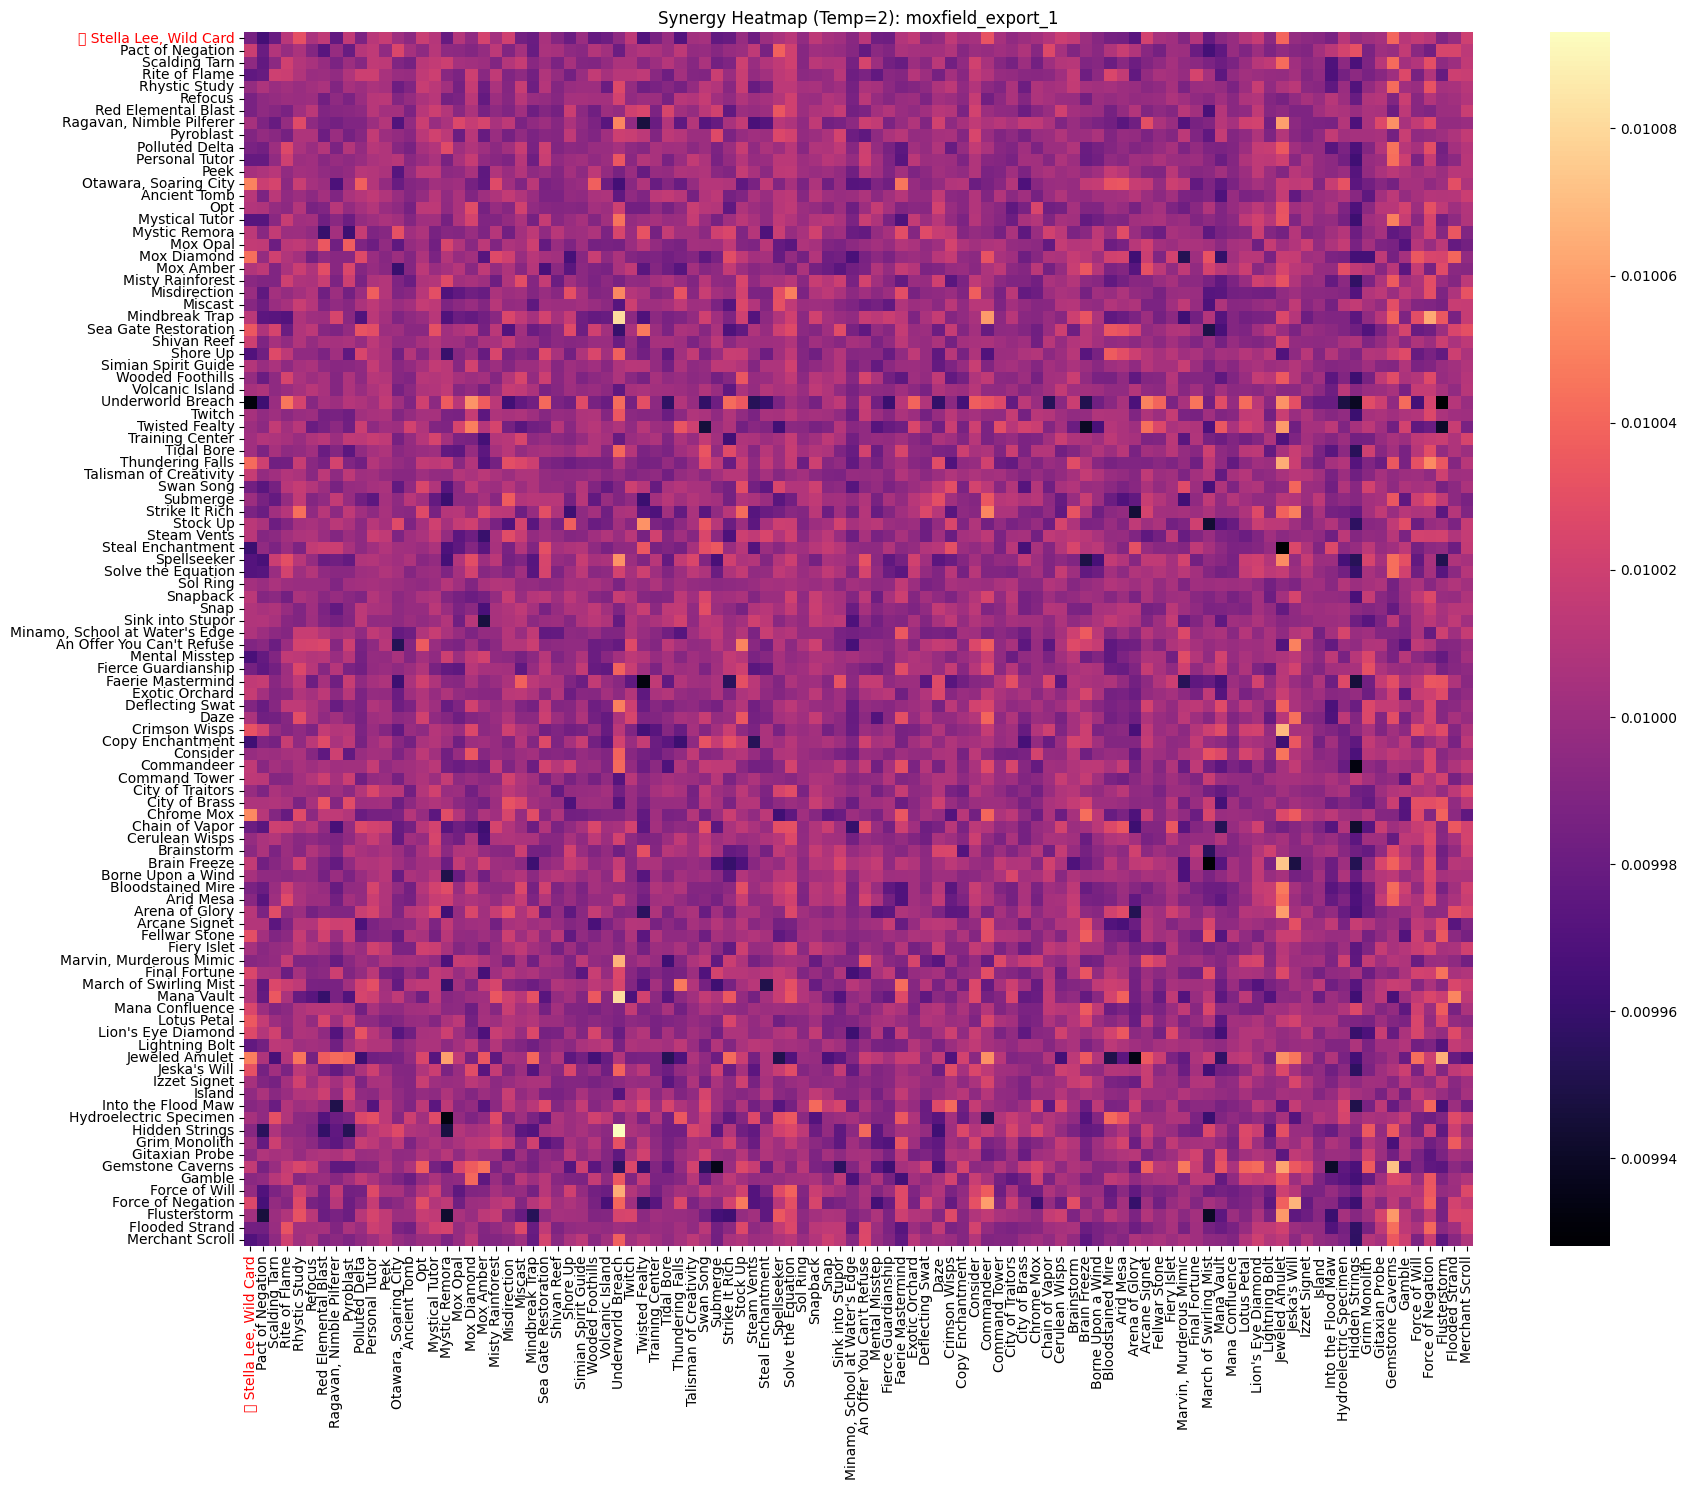

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


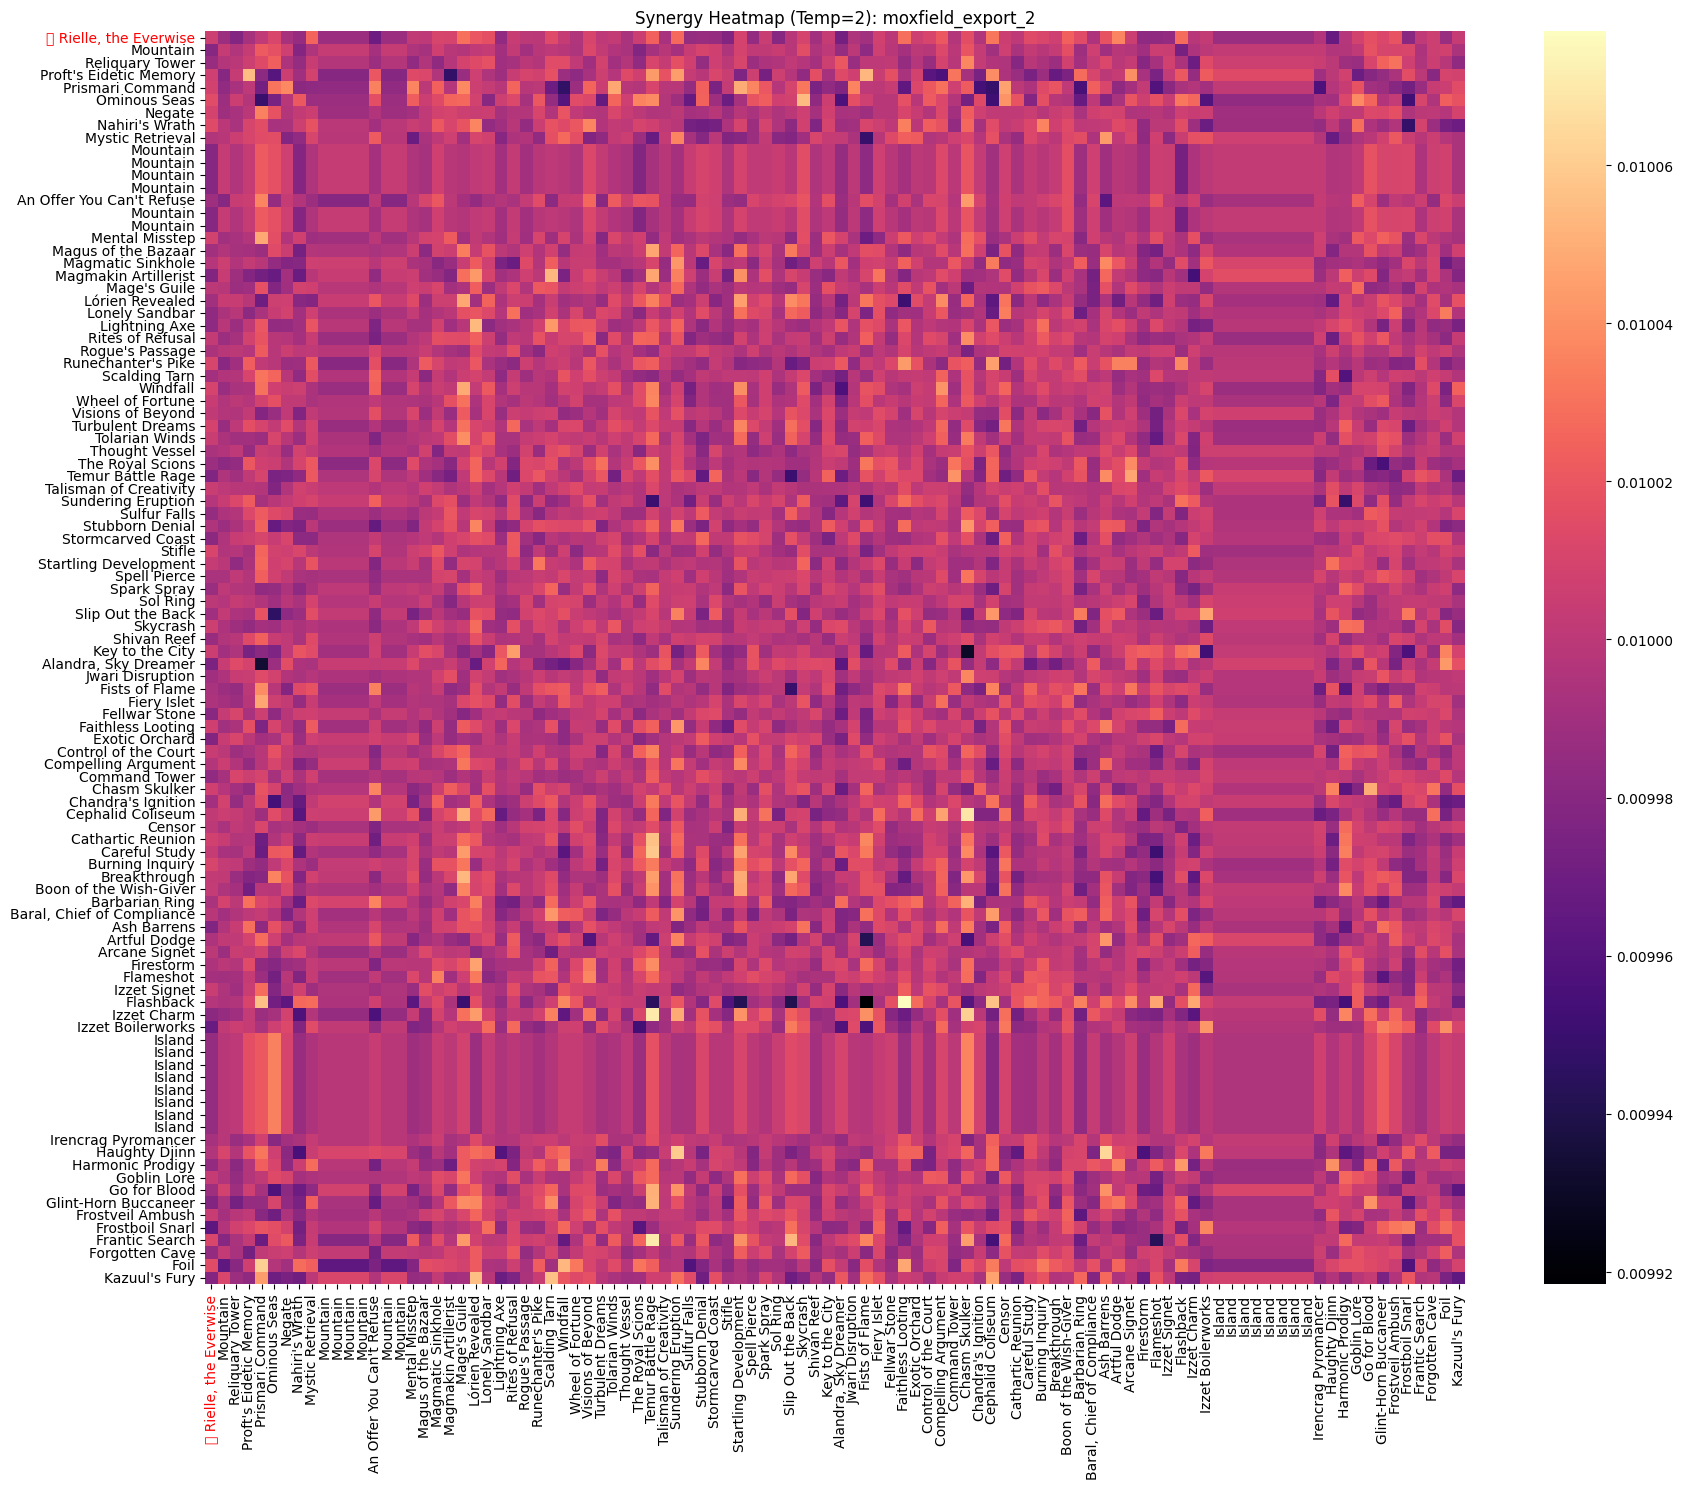

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


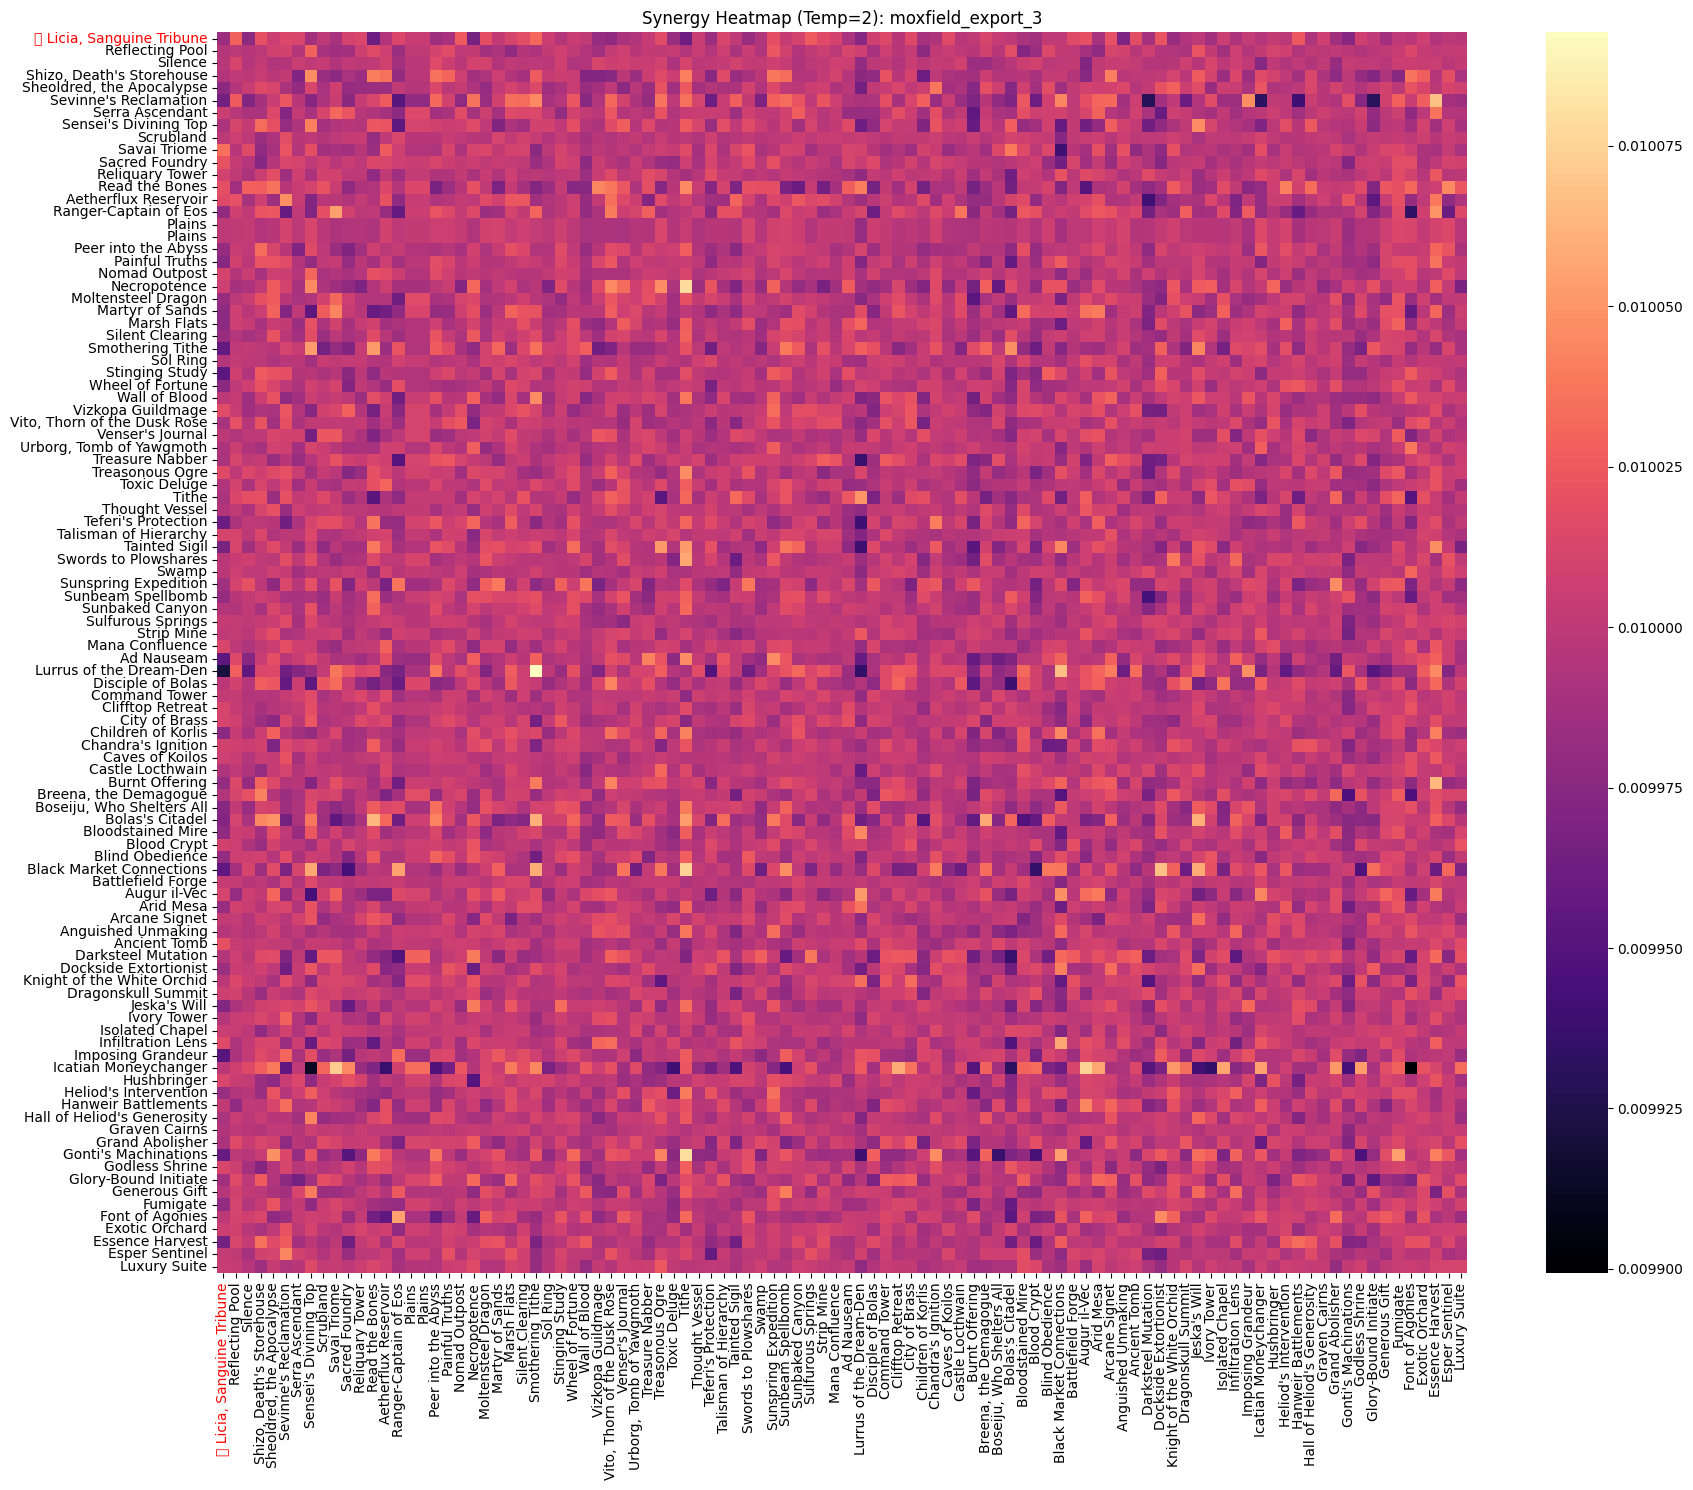

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


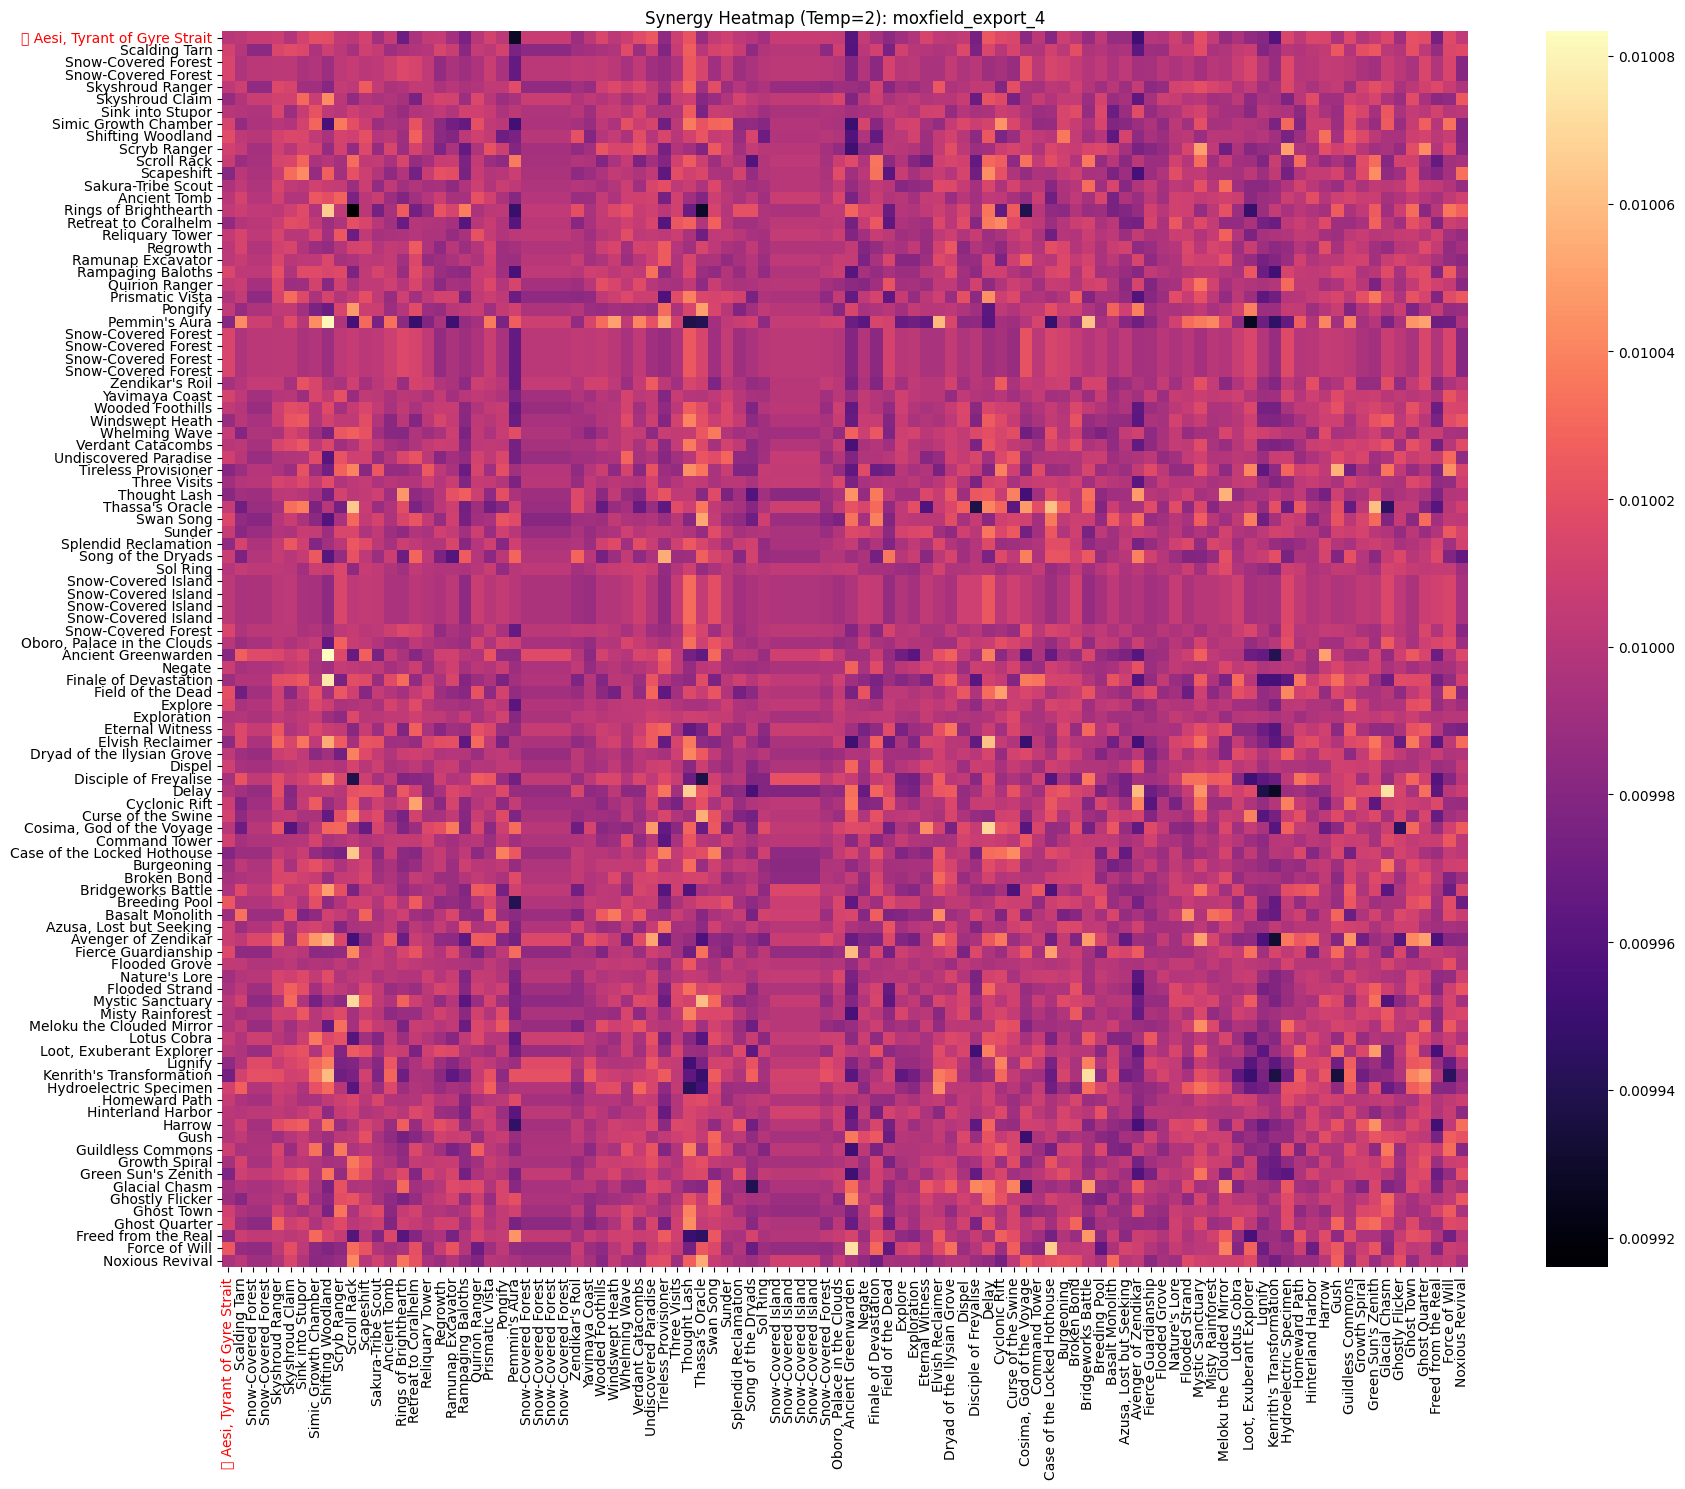

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


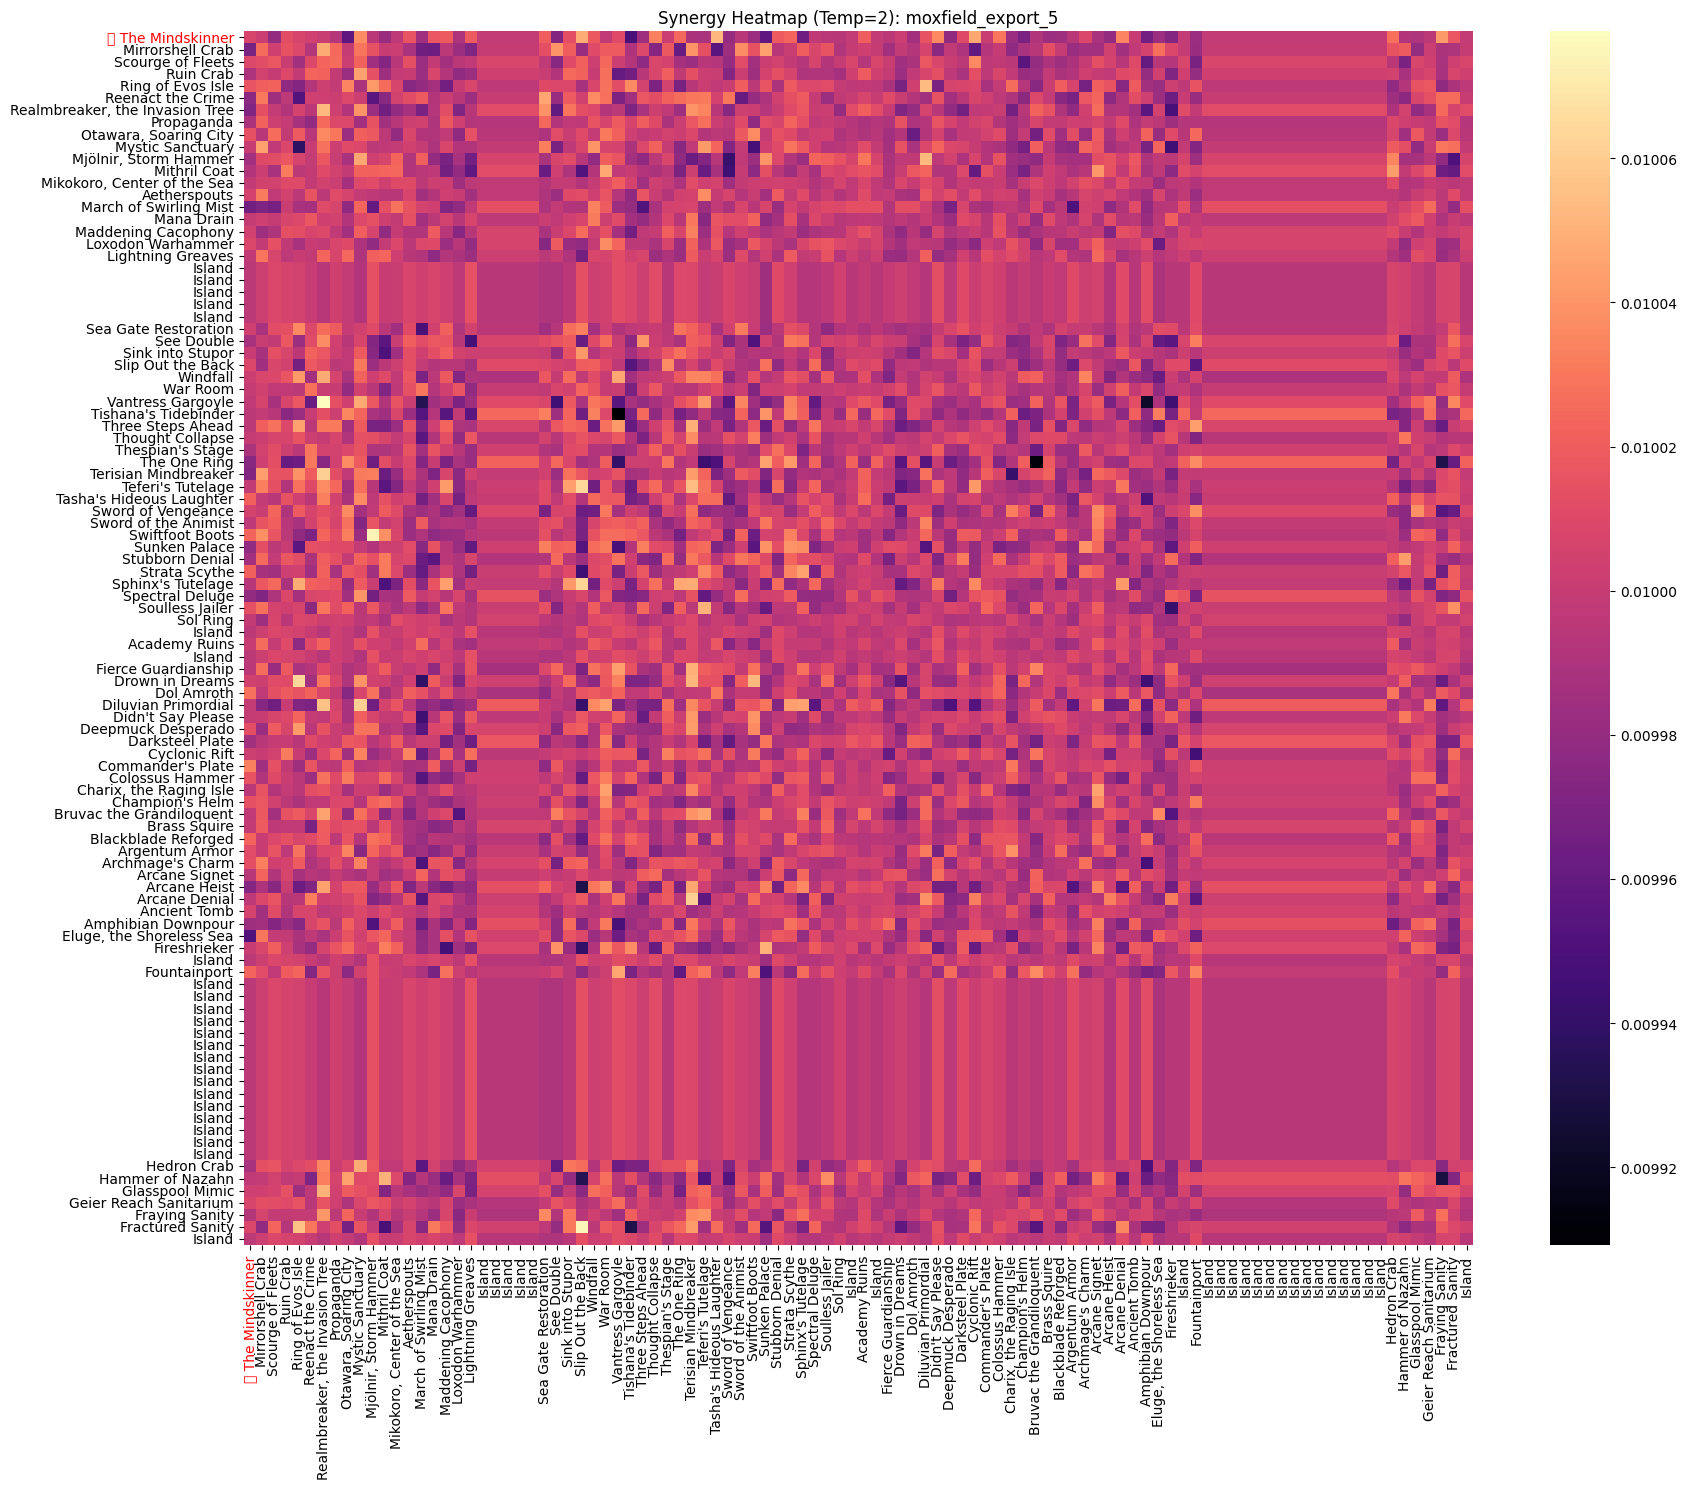

In [8]:
# --- RUNNING THE TUNING ---
# Decrease temp if too blurry (Sharpen)
# Increase temp if too harsh (Soften)
model = MTGDiscoveryModel(len(tag_to_idx))
for d_id, group in df.groupby('deck_id'):
    run_deck_analysis(d_id, group, model, tag_to_idx, temp=2)

1. Text $\rightarrow$ 384D Vectors (latent_features)
2. 384D Vectors $\xrightarrow{KMeans}$ Color Labels
3. 384D Vectors $\xrightarrow{t-SNE}$ X, Y, Z Coordinates
4. Graph = (X, Y, Z Coordinates) + (Color Labels)

t-SNE provides coordinates and K Means color.
This is different from the Inter-Deck synergy because it is missing an Inter-Deck dimension where the relationship between the decks are explored.
Here is more about the Cards.

In [9]:
# !pip install -U sentence-transformers

# Load the Pre-trained Model
# This model 'understands' English mechanics out of the box
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [10]:
# Convert card text to vectors (Embeddings)
df['cleaned_effects'] = df['effects_line'].apply(clean_description)

card_descriptions = (
    df['name'] + " | " +
    df['type_line'] + " | " +
    df['mana_cost'].fillna('') + " | " +
    df['cleaned_effects'] + " | " +
    "Produces: " + df['mana_production'].fillna('Nothing')
).tolist()

# Encode using Sentence Transformer
# This takes the rich description and turns it into a 384-dimensional vector
latent_features = model.encode(card_descriptions, show_progress_bar=True)

# 3. Dimensionality Reduction (T-SNE)
# 2D
tsne_2D = TSNE(n_components=2, perplexity=30, random_state=42)
vis_dims_2D = tsne_2D.fit_transform(latent_features)

# 3D
tsne_3D = TSNE(n_components=3, perplexity=30, random_state=42)
vis_dims_3D = tsne_3D.fit_transform(latent_features)

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

In [14]:
# 2D Interactive Plot (No Color)
fig_2d_basic = px.scatter(
    df,
    x=vis_dims_2D[:, 0],
    y=vis_dims_2D[:, 1],
    hover_name='name',
    title="2D Latent Feature Space (Interactive)",
    template='plotly_dark'
)

# Set a uniform color for all points
fig_2d_basic.update_traces(marker=dict(size=8, opacity=0.7, color='cyan', line=dict(width=0.5, color='white')))
fig_2d_basic.show()

# 3D Interactive Plot (No Color)
fig_3d_basic = px.scatter_3d(
    df,
    x=vis_dims_3D[:, 0],
    y=vis_dims_3D[:, 1],
    z=vis_dims_3D[:, 2],
    hover_name='name',
    title="3D Latent Feature Space (Interactive)",
    template='plotly_dark'
)

# Set a uniform color for all points
fig_3d_basic.update_traces(marker=dict(size=4, opacity=0.8, color='cyan'))
fig_3d_basic.show()

In [13]:
# Create a clean string for the cluster role for the legend
df['cluster_label'] = df['cluster_role'].apply(lambda x: f"Role {x}")

fig_2d = px.scatter(
    df,
    x=vis_dims_2D[:, 0],
    y=vis_dims_2D[:, 1],
    color='cluster_label',
    hover_name='name',
    hover_data={
        'type_line': True,
        'mana_cost': True,
        'cluster_role': True
    },
    title="2D Card Role Clusters (Interactive)",
    template='plotly_dark',
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig_2d.update_traces(marker=dict(size=8, opacity=0.7, line=dict(width=0.5, color='white')))
fig_2d.show()

fig_3d = px.scatter_3d(
    df,
    x=vis_dims_3D[:, 0],
    y=vis_dims_3D[:, 1],
    z=vis_dims_3D[:, 2],
    color='cluster_label',
    hover_name='name',
    hover_data=['type_line', 'cmc'],
    title="3D Latent Card Role Space",
    template='plotly_dark',
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig_3d.update_traces(marker=dict(size=4, opacity=0.8))
fig_3d.show()

In [ ]:
def visualize_cluster_contents(df, n_clusters, tag_to_idx, idx_to_tag):
    print("=== MTG LATENT ROLE ANALYSIS ===")

    # Data Dictionary Sample for the report
    print("\n[Data Dictionary Sample]")
    sample_tags = list(tag_to_idx.keys())[10:18] # Shifted to see variety
    for t in sample_tags:
        print(f"  Token: '{t}' -> Index: {tag_to_idx[t]}")

    for i in range(n_clusters):
        print(f"\n" + "="*60)
        print(f"🟦 CLUSTER {i}: DISCOVERED ROLE")
        print("="*60)

        # 1. Filter cards in this cluster
        cluster_df = df[df['cluster_role'] == i]

        # 2. Sample Card Names
        sample_names = cluster_df['name'].head(8).tolist()
        print(f"📍 Sample Cards: {', '.join(sample_names)}")

        # 3. Retrace & Aggregate ALL Data Sources
        all_cluster_tokens = []
        for _, row in cluster_df.iterrows():
            # Match the input logic used in your Latent Feature Extraction
            tokens = (
                row['gen_tags'] +
                row['man_tags'] +
                get_tokens(row['effects_line']) +
                get_tokens(row['type_line']) +
                get_tokens(row['mana_cost'], is_mana=True) +
                get_tokens(row['mana_production'], is_mana=True)
            )
            # Only keep tokens that are in our vocabulary
            all_cluster_tokens.extend([t for t in tokens if t in tag_to_idx])

        # Get the top 15 most common descriptors for a richer profile
        common_tokens = Counter(all_cluster_tokens).most_common(15)

        print("\n🔑 Defining Keywords (Retraced):")
        token_str = ""
        # Group them visually for the output
        for token, count in common_tokens:
            if token not in ["EMPTY_DATA", "PAD"]:
                idx = tag_to_idx[token]
                token_str += f"• {token}({idx})  "
        print(token_str)

        # 4. Role Interpretation
        # Filter out generic types to find the actual 'Action'
        meaningful_tokens = [t for t, c in common_tokens if t not in ['creature', 'legendary', 'sorcery', 'instant']]
        top_role = meaningful_tokens[0] if meaningful_tokens else common_tokens[0][0]

        print(f"\n💡 Likely Latent Role: Focuses on '{top_role}' interactions.")

In [ ]:
# Run the visualization
visualize_cluster_contents(df, n_clusters, tag_to_idx, idx_to_tag)

=== MTG LATENT ROLE ANALYSIS ===

[Data Dictionary Sample]
  Token: 'Battle Rage' -> Index: 11
  Token: 'Battle-Rage' -> Index: 12
  Token: 'Battlecruiser' -> Index: 13
  Token: 'Big Game Hunter' -> Index: 14
  Token: 'Blood Legion' -> Index: 15
  Token: 'Blood Rush' -> Index: 16
  Token: 'Bloodline' -> Index: 17
  Token: 'Bloodline Champions' -> Index: 18

🟦 CLUSTER 0: DISCOVERED ROLE
📍 Sample Cards: Ancient Tomb, Arena of Glory, City of Brass, City of Traitors, Command Tower, Exotic Orchard, Gemstone Caverns, Mana Confluence

🔑 Defining Keywords (Retraced):
• land(577)  • tap-ability(720)  • enters(501)  • legendary(583)  • creature(448)  • {c}(791)  • may(601)  • mana(597)  • color(424)  • control(431)  • one(624)  • graveyard(549)  • tapped(721)  • {u}(797)  • {any}(789)  

💡 Likely Latent Role: Focuses on 'land' interactions.

🟦 CLUSTER 1: DISCOVERED ROLE
📍 Sample Cards: Island, Volcanic Island, Island, Island, Island, Island, Island, Island

🔑 Defining Keywords (Retraced):
• tap-